# Кластеризация видов пингвинов
Автор: Топорова Е.В.  
Дата: 18.11.2025

## Цель и задачи работы
Цель: изучение методов кластеризации.

Задачи:
1. Выбрать массив данных, описать параметры. Примечание: тип задачи «классификация», «кластеризация».
2. Провести дескриптивный анализ, оценить согласованность выборок с нормальным распределением. В соответствии с результатами обосновать выбор методов кластеризации. Проверить условия решения задачи, в том числе выбранными методами.
3. Отобрать наиболее информативные признаки при необходимости. 
4. Стандартизировать переменные. 
5. Построить рассеивания, диаграммы рассеивания (составные диаграммы категоризованные диаграммы рассеяния) по выбранным переменным. Интерпретировать результаты, оценить возможное количество кластеров, тип кластерной структуры. 
6. Решить задачу кластеризации двумя методами (k-средних, иерархический, EM, DBSCAN и др). Рекомендуется выбирать методы из разных групп. 
7. Оценить качество построенных моделей (в т.ч. расстояние между кластерами, внутрикластерные расстояния, компактность кластеров, центры кластеров, силуэт и т.д.). При необходимости рассчитать внешние метрики. 
8. Оценить значимость признаков. 
9. Провести сравнительный анализ решений. 
10. Исследовать влияние параметров одного из методов на качество решения, оценить полученные результаты. 
11. Интерпретировать результаты. 

## Описание данных

Для выполнения работы был выбран датасет `Кластеризация видов пингвинов (Clustering Penguins Species)`, в котором содержатся следующие признаки:
- `culmen_length_mm` - длина клюва, числовой признак, единица измерения: мм;
- `culmen_depth_mm` - высота надклювья, числовой признак, единица измерения: мм;
- `flipper_length_mm` - длина ласт, числовой признак, единица измерения: мм;
- `body_mass_g` - масса тела, числовой признак, единица измерения: гр;
- `sex` - пол, категориальный признак.

Также в данных есть метки класса - `species` (виды пингвинов). 

---
## 1 Загрузка данных и знакомство с ними
Загрузим необходимые для работы библиотеки.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import normalized_mutual_info_score, fowlkes_mallows_score
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

Загрузим данные.

In [2]:
df_with_class = pd.read_csv('penguins_full.csv')

Данные предназначены для классификации, но в нашем случае понадобятся только при расчете внещних метрик качества кластеризации, поэтому временно уберем их, создав второй датафрейм.

In [3]:
df = df_with_class.drop(columns=['species'])

Изучим данные.

In [4]:
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df_with_class.head())

Размер датасета: (344, 5)

Первые 5 строк:
  species  culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
0  Adelie              39.1             18.7              181.0       3750.0   
1  Adelie              39.5             17.4              186.0       3800.0   
2  Adelie              40.3             18.0              195.0       3250.0   
3  Adelie               NaN              NaN                NaN          NaN   
4  Adelie              36.7             19.3              193.0       3450.0   

      sex  
0    male  
1  female  
2  female  
3     NaN  
4  female  


## 2 Предобработка данных
### 2.1 Пропущенные значения
Проверим данные на наличие пропущенных значений.

In [5]:
print('Количество пропущенных значений:\n', df.isnull().sum())

Количество пропущенных значений:
 culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


Пропущенные значения составляют не более 5% данных (примерно 2.6 %), следовательно, их можно просто удалить. Сначала обработаем датафрейм без меток класса.

In [6]:
df = df.dropna(subset=['culmen_length_mm', 'culmen_depth_mm', 
                        'flipper_length_mm', 'body_mass_g'])

df = df.dropna(subset=['sex'])

print('Проверка пропущенных значений:\n', df.isnull().sum())

Проверка пропущенных значений:
 culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


Из датафрейма с метками класса также нужно удалить пропущенные значения.

In [7]:
df_with_class = df_with_class.dropna(subset=['culmen_length_mm', 'culmen_depth_mm', 
                                             'flipper_length_mm', 'body_mass_g'])
df_with_class = df_with_class.dropna(subset=['sex'])

print('Проверка пропущенных значений:\n', df_with_class.isnull().sum())

Проверка пропущенных значений:
 species              0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


### 2.2 Выбросы
Далее необходимо провести анализ числовых признаков на выбросы.

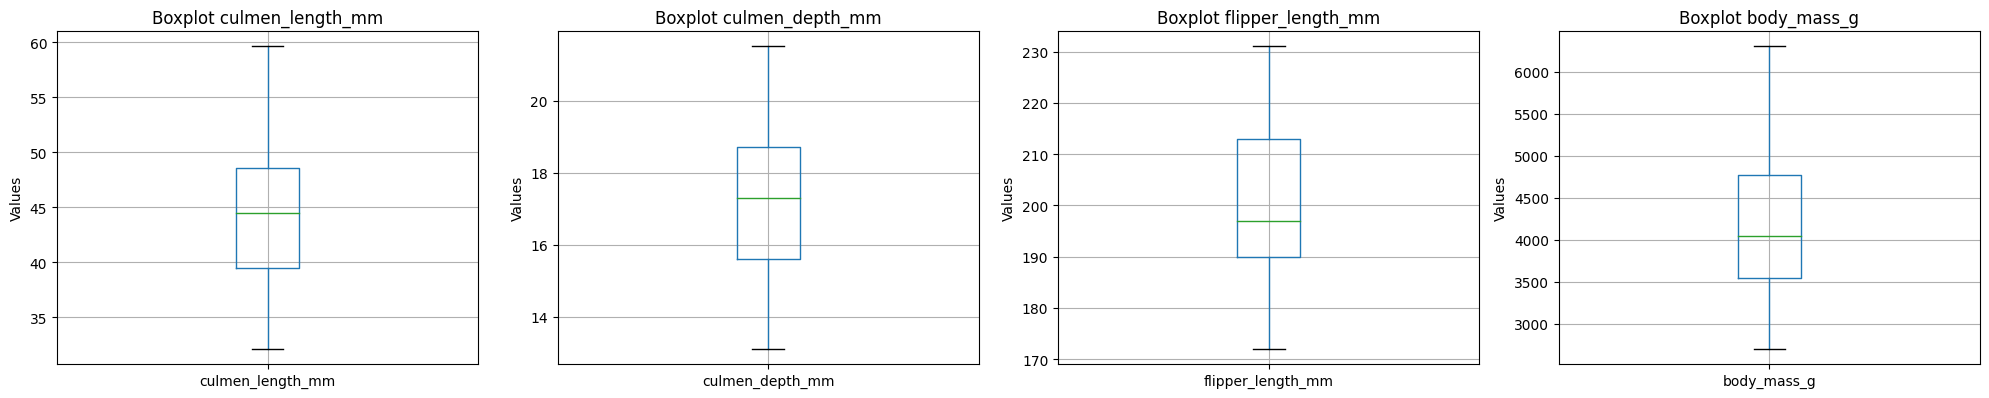

In [8]:
features = df.columns[:4]
n_features = len(features)

fig, axes = plt.subplots(4, 4, figsize=(20, 15))
axes = axes.ravel()

for i, feature in enumerate(features):
    if i < len(axes):
        df.boxplot(column=feature, ax=axes[i])
        axes[i].set_title(f'Boxplot {feature}')
        axes[i].set_ylabel('Values')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

В результате построения ящиков с усами можно заметить, что выбросы в данных отсутствуют.

### 2.3 Отбор наиболее информативных признаков. Корреляционный анализ

Половой признак `sex` не должен стать основой для разбиения пингвинов по видам, поэтому его стоит исключить из рассмотрения. Пингвины одного вида имеют схожую морфологию независимо от пола. Если же данный признак оставить, и он окажет большое влияние, то кластеры сформируются скорее по полу, чем по видам, что не имеет практической ценности для данной задачи. Кроме того, признаки при проведении кластеризации должны быть числовыми.

Также необходимо проверить остальные признаки на независимость, потому что мультиколлинеарность искажает расстояния между точками и алгоритмы кластеризации хуже работают с зависимыми признаками.

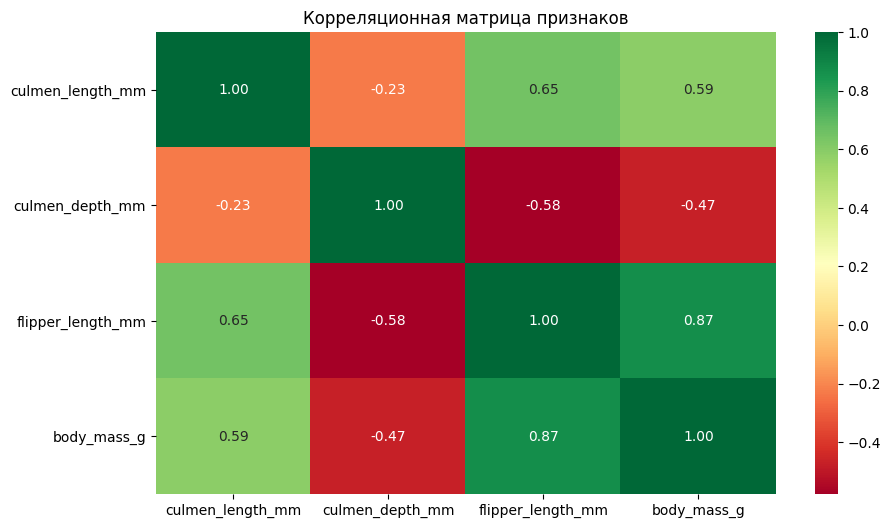

In [9]:
numerical_features = ['culmen_length_mm', 'culmen_depth_mm', 
                     'flipper_length_mm', 'body_mass_g']

plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Корреляционная матрица признаков")
plt.show()

Так как между `flipper_length_mm` и `body_mass_g` присутствует сильная корреляция, стоит исключить один из данных признаков. Для этого проведем дисперсионный анализ.

Результаты дисперсионного анализа (ANOVA):
          Признак  F-статистика       p-value
flipper_length_mm    567.406992 1.587418e-107
 culmen_length_mm    397.299437  1.380984e-88
  culmen_depth_mm    344.825082  1.446616e-81
      body_mass_g    341.894895  3.744505e-81


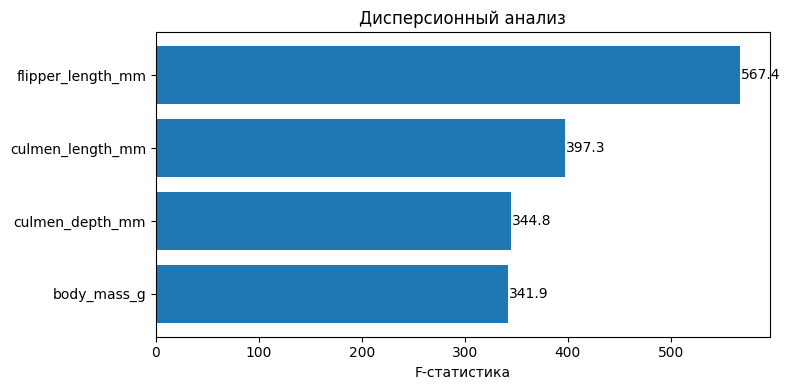

In [10]:
anova_results = []

for feature in numerical_features:
    groups = [df_with_class[df_with_class['species'] == sp][feature].dropna() 
              for sp in df_with_class['species'].unique()]
    
    f_stat, p_value = f_oneway(*groups)
    
    anova_results.append({
        'Признак': feature,
        'F-статистика': f_stat,
        'p-value': p_value
    })

anova_df = pd.DataFrame(anova_results)
anova_df = anova_df.sort_values('F-статистика', ascending=False)

print("Результаты дисперсионного анализа (ANOVA):")
print(anova_df.to_string(index=False))

plt.figure(figsize=(8, 4))

bars = plt.barh(anova_df['Признак'], anova_df['F-статистика'])

plt.xlabel('F-статистика')
plt.title('Дисперсионный анализ')
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}', ha='left', va='center')
plt.tight_layout()
plt.show()

По результатам дисперсионного анализа можно заметить, что `body_mass_g` вносит наименьший вклад в общую информацию, поэтому исключим именно этот признак.

### 2.4 Дескриптивный анализ
Выведем описательные статистики числовых признаков.

In [11]:
numerical_features2 = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm']

print("Дескриптивный анализ:")

summary = pd.DataFrame({
    "Среднее": df[numerical_features2].mean(numeric_only=True),
    "Медиана": df[numerical_features2].median(numeric_only=True),
    "Мода": df[numerical_features2].mode().iloc[0],
    "Ст. отклонение": df[numerical_features2].std(numeric_only=True),
    "Мин": df[numerical_features2].min(),
    "Макс": df[numerical_features2].max()
})

print(summary.round(2))

Дескриптивный анализ:
                   Среднее  Медиана   Мода  Ст. отклонение    Мин   Макс
culmen_length_mm     43.99     44.5   41.1            5.47   32.1   59.6
culmen_depth_mm      17.16     17.3   17.0            1.97   13.1   21.5
flipper_length_mm   200.97    197.0  190.0           14.02  172.0  231.0


Посмотрим на распределения признаков.

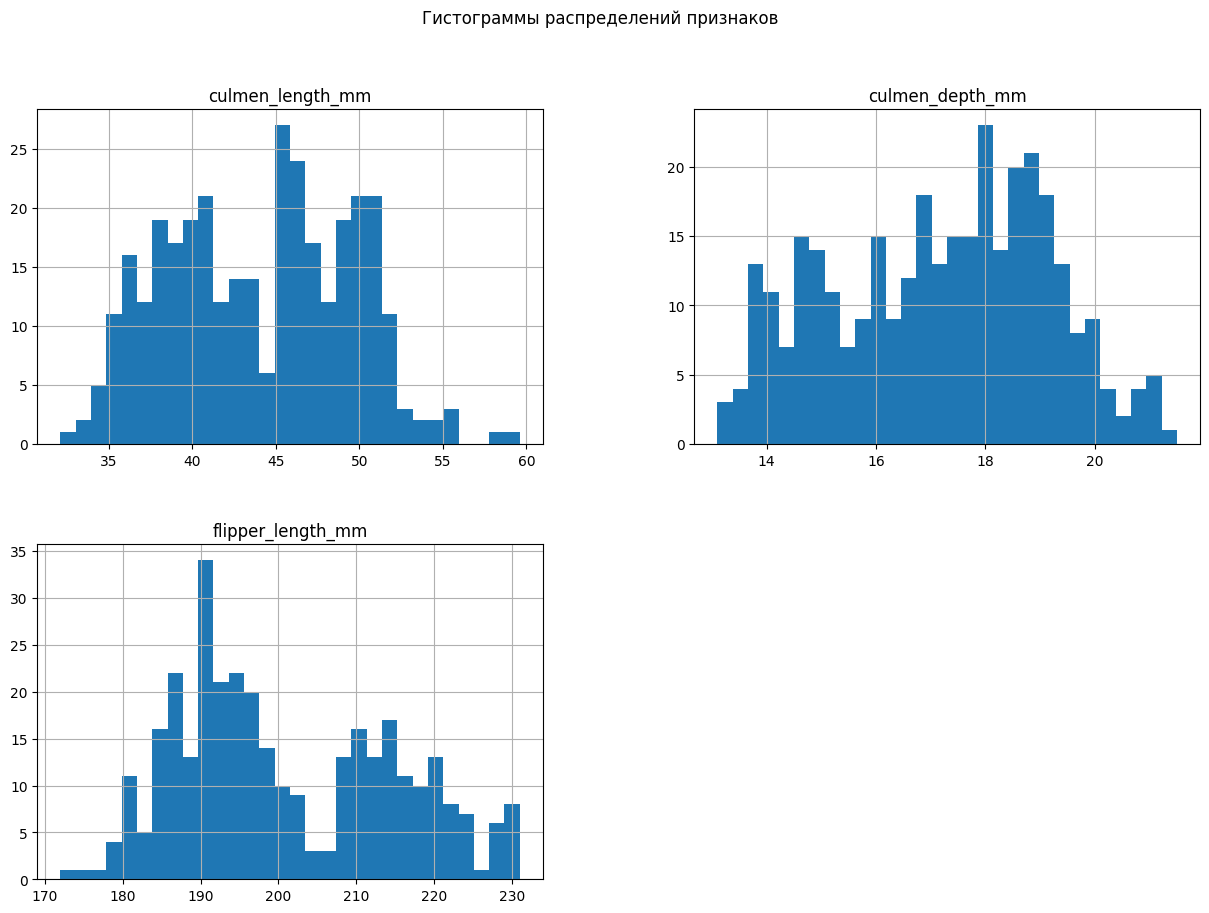

In [12]:
df[numerical_features2].hist(bins=30, figsize=(15, 10))
plt.suptitle("Гистограммы распределений признаков")
plt.show()

Распределения признаков не согласуются с нормальным, кроме того, признаки представлены в разных единицах измерения, поэтому необходимо применить стандартизацию.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numerical_features2])
df_scaled = pd.DataFrame(X_scaled, columns=df[numerical_features2].columns)

print("Статистика после обработки:")
print(df_scaled.describe().round(2))

Статистика после обработки:
       culmen_length_mm  culmen_depth_mm  flipper_length_mm
count            333.00           333.00             333.00
mean              -0.00            -0.00               0.00
std                1.00             1.00               1.00
min               -2.18            -2.07              -2.07
25%               -0.82            -0.80              -0.78
50%                0.09             0.07              -0.28
75%                0.84             0.78               0.86
max                2.86             2.20               2.15


In [14]:
print("Размер датасета:", df_scaled.shape)

Размер датасета: (333, 3)


### 2.5 Промежуточный вывод
В результате предобработки данных было выполнено следующее:
- удалены пропуски,
- выбросы не обнаружены,
- исключен из рассмотрения категориальный признак `sex`,
- исключен признак `body_mass_g`, коррелирующий с другим и вносящий наименьший вклад в общую дисперсию,
- данные стандартизированы.

Датасет сократился на 2.6%, осталось 3 признака и 333 элемента.

---
## 3 Выбор методов и определение их параметров
### 3.1 Диаграммы рассеивания
Выведем диаграммы рассеивания для оценки необходимого количества кластеров.

<Figure size 2000x2000 with 0 Axes>

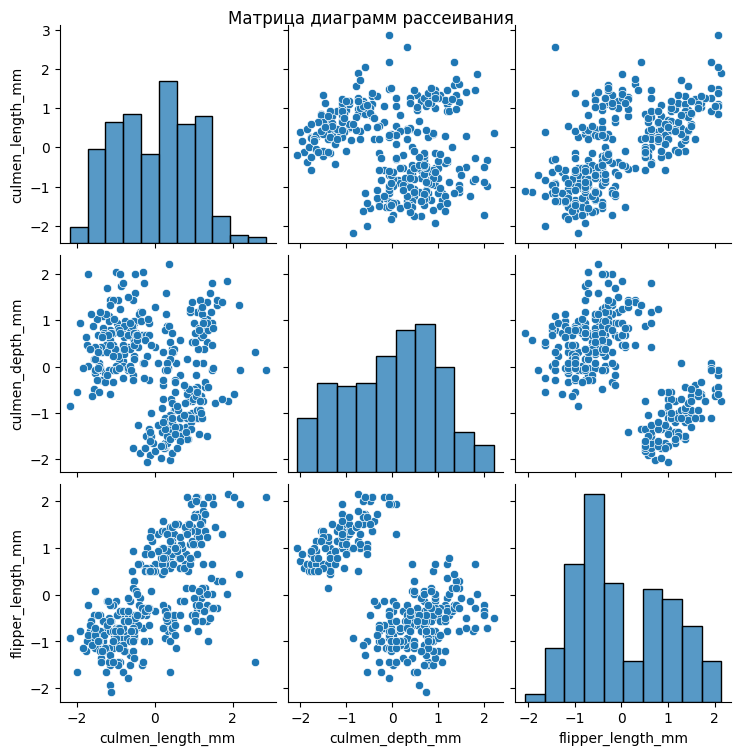

In [15]:
plt.figure(figsize=(20, 20))
sns.pairplot(df_scaled)
plt.suptitle('Матрица диаграмм рассеивания', y=1)
plt.show()

По диаграммам рассеивания можно предположить, что оптимальное количество кластеров - 2-3, но третий кластер совсем небольшой и почти сливается с остальными.

На диаграммах с двумя кластерами можно заметить, что они слегка вытянутые, напоминают овалы.

На диаграммах с тремя кластерами похоже, что кластеры с центрами накладываются на разреженный фон из редко расположенных объектов.

### 3.2 Выбор методов согласно структуре кластеров
Можно попробовать использовать метод k-средних, так как данные представляют собой отдельные "облака". Однако эти "облака" немного разного размера и присутствуют обособленные точки, которые могут плохо влиять на работу алгоритма.

Алгоритм GMM, вероятнее, лучше подойдет для датасета, так как он позволяет моделировать кластеры различной формы и справляется с ситуациями, когда границы между кластерами нечеткие.

### 3.3 Метод локтя и график силуэта
Попробуем определить количество кластеров также с помощью графиков локтя и силуэта.

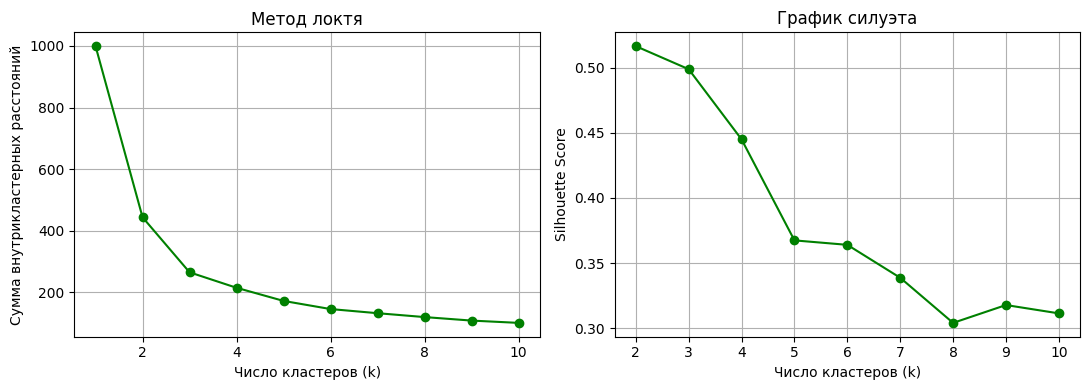

In [16]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(11,4))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), inertia, 'go-')
plt.title("Метод локтя")
plt.xlabel("Число кластеров (k)")
plt.ylabel("Сумма внутрикластерных расстояний")
plt.grid(True)

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'go-')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Silhouette Score')
plt.title('График силуэта')
plt.grid(True)
plt.tight_layout()
plt.show()

По методу локтя можно выбрать 2-3 кластера, так как после 3 график изменяется гораздо медленнее.

По графику силуэта видно, что стоит выбрать 2 кластера, так как это ближайшее большое значение, после которого график убывает.

Таким образом, оптимальным количеством кластеров для k-means будет 2.

### 3.4 Определение параметров GMM
Для алгоритма GMM нужно определить параметры `n_components` и `covariance_type`.

`covariance_type='full'` указывает на то, что кластеры имеют разные формы, размеры и ориентацию, что подходит для представленных данных.

Для выбора `n_components` есть практический метод – построение графика BIC.

Text(0.5, 1.0, 'BIC для выбора числа компонент')

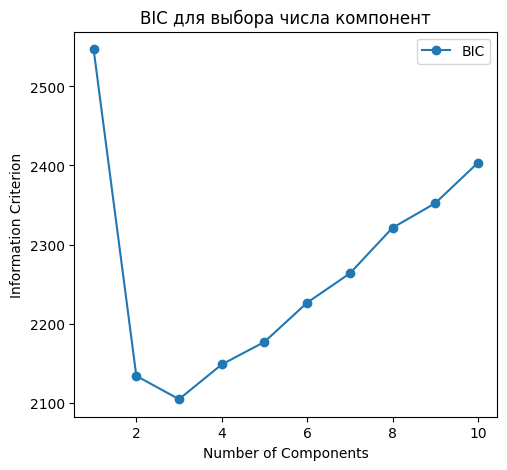

In [17]:
n_components_range = range(1, 11)
bics = []

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(n_components_range, bics, 'o-', label='BIC')
plt.xlabel('Number of Components')
plt.ylabel('Information Criterion')
plt.legend()
plt.title('BIC для выбора числа компонент')

BIC достигает минимума при `n_components = 3`. Это значит, что модель с 3 компонентами оптимальна. Дальнейшее увеличение числа компонент приводит к переобучению, а меньшее не улавливает всю структуру данных.

---
## 4 Построение моделей
### 4.1 Запуск моделей
Запустим модель K-Means c `n_clusters=2`.

In [18]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

Запустим модель GMM c `n_components=3` и `covariance_type='spherical'`.

In [19]:
gmm = GaussianMixture(n_components=3, covariance_type='spherical', n_init=10, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

### 4.2 Расчет внутренних метрик
Рассчитаем и выведем внутренние метрики оценки качества кластеризации.

In [20]:
def calculate_cluster_metrics(X, labels, method_name):
    unique_labels = np.unique(labels)
    metrics = {}
    
    if len(unique_labels) > 1:
        metrics['silhouette'] = silhouette_score(X, labels)
        metrics['calinski_harabasz'] = calinski_harabasz_score(X, labels)
        metrics['davies_bouldin'] = davies_bouldin_score(X, labels)
    else:
        metrics['silhouette'] = metrics['calinski_harabasz'] = metrics['davies_bouldin'] = np.nan
    
    cluster_stats = {}
    for label in unique_labels:
        if label == -1:
            continue
            
        cluster_points = X[labels == label]
        if len(cluster_points) < 2:
            continue
            
        centroid = np.mean(cluster_points, axis=0)
        distances_to_center = np.linalg.norm(cluster_points - centroid, axis=1)
        
        cluster_stats[label] = {
            'size': len(cluster_points),
            'centroid': centroid,
            'compactness': np.mean(distances_to_center),
            'intra_mean': np.mean(pdist(cluster_points)),
            'radius': np.max(distances_to_center)
        }

    if len(cluster_stats) > 1:
        centroids = [stats['centroid'] for stats in cluster_stats.values()]
        inter_distances = pdist(centroids)
        metrics['mean_inter_distance'] = np.mean(inter_distances)
        metrics['min_inter_distance'] = np.min(inter_distances)
    else:
        metrics['mean_inter_distance'] = metrics['min_inter_distance'] = np.nan
    
    return metrics, cluster_stats
kmeans_metrics, kmeans_stats = calculate_cluster_metrics(X_scaled, kmeans_labels, "K-means")
gmm_metrics, gmm_stats = calculate_cluster_metrics(X_scaled, gmm_labels, "GMM")

print("Внутренние метрики качества кластеризации")
metrics_comparison = pd.DataFrame({
    'Метод': ['K-means', 'GMM'],
    'Кластеры': [len(kmeans_stats), len(gmm_stats)],
    'Silhouette': [
        f"{kmeans_metrics['silhouette']:.4f}" if not np.isnan(kmeans_metrics['silhouette']) else 'N/A',
        f"{gmm_metrics['silhouette']:.4f}" if not np.isnan(gmm_metrics['silhouette']) else 'N/A'
    ],
    'Calinski-Harabasz': [
        f"{kmeans_metrics['calinski_harabasz']:.2f}" if not np.isnan(kmeans_metrics['calinski_harabasz']) else 'N/A',
        f"{gmm_metrics['calinski_harabasz']:.2f}" if not np.isnan(gmm_metrics['calinski_harabasz']) else 'N/A'
    ],
    'Davies-Bouldin': [
        f"{kmeans_metrics['davies_bouldin']:.4f}" if not np.isnan(kmeans_metrics['davies_bouldin']) else 'N/A',
        f"{gmm_metrics['davies_bouldin']:.4f}" if not np.isnan(gmm_metrics['davies_bouldin']) else 'N/A'
    ]
})

print(metrics_comparison.to_string(index=False))

def analyze_clusters_structure(X, labels, method_name):
    metrics, cluster_stats = calculate_cluster_metrics(X, labels, method_name)
    
    print(f"\nАнализ структуры кластеров {method_name}")
    cluster_analysis = []
    for label, stats in cluster_stats.items():
        cluster_analysis.append({
            'Кластер': label,
            'Размер': stats['size'],
            'Доля, %': f"{(stats['size'] / len(X) * 100):.1f}",
            'Компактность': f"{stats['compactness']:.4f}",
            'Внутр. расстояние': f"{stats['intra_mean']:.4f}",
            'Радиус': f"{stats['radius']:.4f}"
        })
    
    cluster_df = pd.DataFrame(cluster_analysis)
    print(cluster_df.to_string(index=False))
    
    if not np.isnan(metrics['mean_inter_distance']):
        print(f"\nСреднее межкластерное расстояние: {metrics['mean_inter_distance']:.4f}")
        print(f"Минимальное межкластерное расстояние: {metrics['min_inter_distance']:.4f}")
    
    return cluster_stats, metrics

kmeans_stats, kmeans_metrics = analyze_clusters_structure(X_scaled, kmeans_labels, "K-means")
gmm_stats, gmm_metrics = analyze_clusters_structure(X_scaled, gmm_labels, "GMM")

Внутренние метрики качества кластеризации
  Метод  Кластеры Silhouette Calinski-Harabasz Davies-Bouldin
K-means         2     0.5166            413.91         0.7298
    GMM         3     0.4991            453.90         0.7790

Анализ структуры кластеров K-means
 Кластер  Размер Доля, % Компактность Внутр. расстояние Радиус
       0     213    64.0       1.1663            1.6194 3.0502
       1     120    36.0       0.7962            1.1198 2.5941

Среднее межкластерное расстояние: 2.6892
Минимальное межкластерное расстояние: 2.6892

Анализ структуры кластеров GMM
 Кластер  Размер Доля, % Компактность Внутр. расстояние Радиус
       0      65    19.5       0.8222            1.1632 2.0199
       1     149    44.7       0.8234            1.1639 1.8669
       2     119    35.7       0.7906            1.1101 2.5933

Среднее межкластерное расстояние: 2.4627
Минимальное межкластерное расстояние: 1.9826


### 4.3 Оценка качества построенных моделей согласно внутренним метрикам
**Сравнение методов**  
На основании полученных метрик качества, K-means показывает несколько лучшие результаты для данного набора данных, чем GMM.
- Silhouette: Значительно более высокий показатель у K-means указывает на то, что объекты в кластерах лучше сгруппированы и сильнее отделены от других кластеров.
- Calinski-Harabasz: Более высокий показатель у GMM говорит о том, что кластеры более плотные и хорошо разделены.
- Davies-Bouldin: Более низкий показатель у K-means свидетельствует о лучшей компактности кластеров и их лучшем разделении.

**Анализ кластеров K-means**
- Кластер 0: Крупнейший кластер (64% данных) с умеренной компактностью. Является основной, но несколько неоднородной группой.
- Кластер 1: Меньший кластер (36% данных) с хорошей компактностью. Это хорошо определенная группа объектов.

Минимальное межкластерное расстояние = 2.6892 - это высокое значение указывает на отличное разделение кластеров. Поскольку кластеров всего два, минимальное и среднее расстояния совпадают, что подтверждает четкую границу между кластерами.

**Анализ кластеров GMM**
- Кластер 0: Наименьший кластер (20% данных) с хорошей компактностью.
- Кластер 1: Крупнейший кластер (45% данных) с хорошей компактностью.
- Кластер 2: Средний кластер (36% данных) с хорошей компактностью.

Минимальное межкластерное расстояние = 1.9826 - значительно ниже, чем у K-means. Это указывает на то, что два кластера расположены довольно близко друг к другу, что может объяснить более низкие значения метрик качества. Среднее расстояние = 2.4627 также подтверждает менее выраженное разделение между кластерами по сравнению с K-means.

### 4.4 Расчет внешних метрик

In [21]:
true_labels = df_with_class['species']

def calculate_external_metrics(true_labels, pred_labels):
    le = LabelEncoder()
    true_labels_encoded = le.fit_transform(true_labels)

    ari = adjusted_rand_score(true_labels_encoded, pred_labels)
    nmi = normalized_mutual_info_score(true_labels_encoded, pred_labels)
    fmi = fowlkes_mallows_score(true_labels_encoded, pred_labels)
    
    return ari, nmi, fmi

ari_kmeans, nmi_kmeans, fmi_kmeans = calculate_external_metrics(true_labels, kmeans_labels)
ari_gmm, nmi_gmm, fmi_gmm = calculate_external_metrics(true_labels, gmm_labels)

print("Внешние метрики качества кластеризации")

comparison_df = pd.DataFrame({
    'Метрика': [
        'Adjusted Rand Index (ARI)',
        'Normalized Mutual Information (NMI)', 
        'Fowlkes-Mallows Index (FMI)'
    ],
    'K-means': [
        f"{ari_kmeans:.4f}",
        f"{nmi_kmeans:.4f}",
        f"{fmi_kmeans:.4f}"
    ],
    'GMM': [
        f"{ari_gmm:.4f}",
        f"{nmi_gmm:.4f}", 
        f"{fmi_gmm:.4f}"
    ]
})

print(comparison_df.to_string(index=False))

Внешние метрики качества кластеризации
                            Метрика K-means    GMM
          Adjusted Rand Index (ARI)  0.6468 0.8977
Normalized Mutual Information (NMI)  0.7474 0.8638
        Fowlkes-Mallows Index (FMI)  0.8152 0.9347


### 4.5 Оценка качества построенных моделей согласно внешним метрикам

Алгоритм GMM c 3 кластерами практически идеально воспроизводит истинное видовое разделение пингвинов, в то время как k-means показывает умеренное соответствие. Это говорит о том, что в исходных данных все же присутствует 3 вида.

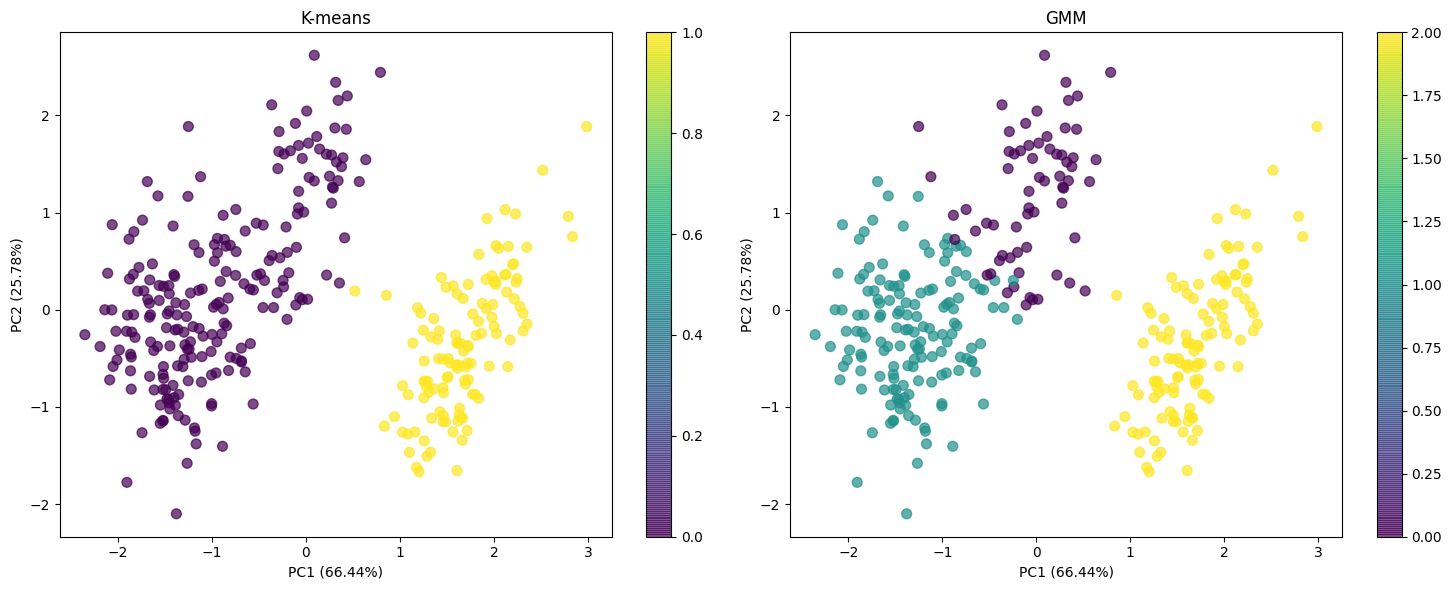

In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7, s=50)
axes[0].set_title('K-means')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')

plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='viridis', alpha=0.7, s=50)
axes[1].set_title('GMM')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')

plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

centroids = scaler.inverse_transform(kmeans.cluster_centers_)

---
## 5 Оценка адекватности полученных решений 
### 5.1 K-Means

In [23]:
print("Центры кластеров K-means")
centroids_analysis = []
for i, centroid in enumerate(centroids):
    centroid_info = {'Кластер': i, 'Размер': kmeans_stats[i]['size']}
    for j, feature in enumerate(df_scaled.columns):
        centroid_info[feature] = f"{centroid[j]:.2f}"
    centroids_analysis.append(centroid_info)

centroids_df_detailed = pd.DataFrame(centroids_analysis)
print(centroids_df_detailed.to_string(index=False))

Центры кластеров K-means
 Кластер  Размер culmen_length_mm culmen_depth_mm flipper_length_mm
       0     213            41.98           18.38            191.89
       1     120            47.57           15.01            217.08


Кластер 0 (213 особей) вероятно, представляет один из видов пингвинов с умеренными размерами.<br>
Кластер 1 (120 особей) отличается более длинным, но менее глубоким клювом и большими размерами. <br>
Такое разделение по морфологическим признакам вполне может соответствовать действительности.

### 5.2 GMM

In [24]:
gmm_centers = gmm.means_

scaler.fit(df[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm']])
gmm_centers_original = scaler.inverse_transform(gmm_centers)

print("Центры кластеров GMM")
gmm_centers_analysis = []
for i, center in enumerate(gmm_centers_original):
    cluster_size = np.sum(gmm_labels == i)
    center_info = {'Кластер': i, 'Размер': cluster_size}
    center_info['culmen_length_mm'] = f"{center[0]:.2f}"
    center_info['culmen_depth_mm'] = f"{center[1]:.2f}" 
    center_info['flipper_length_mm'] = f"{center[2]:.2f}"
    gmm_centers_analysis.append(center_info)

gmm_centers_df_detailed = pd.DataFrame(gmm_centers_analysis)
print(gmm_centers_df_detailed.to_string(index=False))

Центры кластеров GMM
 Кластер  Размер culmen_length_mm culmen_depth_mm flipper_length_mm
       0      65            49.15           18.75            197.16
       1     149            38.98           18.22            189.69
       2     119            47.56           15.01            217.15


GMM, в отличие от k-means, выявил 3 вида пингвинов.  
Кластер 2 почти идентичен кластеру 1 в k-means, значит это устойчивая, хорошо различимая группа крупных пингвинов.  
А вот кластер 0 из k-means был разделен на 2 подгруппы: кластеры под номером 0 в k-means и 1 в gmm схожи, а кластер 0 - уникальная группа с самым длинным и глубоким клювом, средних размеров, выявленная GMM.

### 5.3 Промежуточный вывод
Благодаря внутренним метрикам и анализу кластеров можно сделать вывод, что 2 вида очень схожи между собой и трудно различимы, поэтому методы для оценки количества кластеров выдавали спорные результаты (2-3 кластера).

---
## 6 Оценка важности признаков
### 6.1 Размах средних

In [25]:
print("k-means:")
df_with_class['cluster_kmeans'] = kmeans_labels
features_used = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm']
cluster_means = df_with_class.groupby('cluster_kmeans')[features_used].mean()
feature_info = (cluster_means.max() - cluster_means.min()).sort_values(ascending=False)

for feature, importance in feature_info.items():
    print(f"{feature}: {importance:.2f}")

print("\nGMM:")
df_with_class['cluster_gmm'] = gmm_labels
cluster_means = df_with_class.groupby('cluster_gmm')[features_used].mean()
feature_info = (cluster_means.max() - cluster_means.min()).sort_values(ascending=False)

for feature, importance in feature_info.items():
    print(f"{feature}: {importance:.2f}")

k-means:
flipper_length_mm: 25.20
culmen_length_mm: 5.60
culmen_depth_mm: 3.37

GMM:
flipper_length_mm: 27.52
culmen_length_mm: 10.38
culmen_depth_mm: 3.67


Результат k-means:
- `flipper_length_mm` (25.20) - самый важный для разбиения признак (сильно варьирует между кластерами);
- `culmen_depth_mm` (3.37) - наименее важный.

Результат GMM:
- `flipper_length_mm` (27.52) - снова самый важный;
- `culmen_depth_mm` (3.67) - наименее важный.

Оба метода согласны: длина крыла `flipper_length_mm` важнее длины `culmen_length_mm` и глубины клюва `culmen_depth_mm`.

### 6.2 F-статистика. Дисперсионный анализ

In [26]:
f_values, _ = f_classif(df_with_class[features_used], df_with_class['cluster_kmeans'])
for feature, f_val in zip(features_used, f_values):
    print(f"{feature}: F-value = {f_val:.2f}")
print("\n")
f_values_gmm, _ = f_classif(df_with_class[features_used], df_with_class['cluster_gmm'])
for feature, f_val in zip(features_used, f_values_gmm):
    print(f"{feature}: F-value = {f_val:.2f}")


culmen_length_mm: F-value = 105.75
culmen_depth_mm: F-value = 695.93
flipper_length_mm: F-value = 978.08


culmen_length_mm: F-value = 444.65
culmen_depth_mm: F-value = 355.01
flipper_length_mm: F-value = 613.83


Оба метода единогласно считают `flipper_length_mm` самым важным признаком.

`culmen_depth_mm` важен для k-means (компактные кластеры), но теряет важность в GMM.

GMM лучше использует `culmen_length_mm` для разделения.

Разные алгоритмы кластеризации по-разному «видят» структуру данных.

---
## 7 Исследование влияния количества кластеров на качество решения алгоритма k-means

Сравнительная таблица метрик качества кластеризации K-means
 K Silhouette Calinski-Harabasz Davies-Bouldin Ср. межкл. расст. Мин. межкл. расст.    ARI    NMI    FMI
 2     0.5166            413.91         0.7298            2.6892             2.6892 0.6468 0.7474 0.8152
 3     0.4989            455.94         0.7925            2.4584             1.9630 0.9199 0.8870 0.9487
 4     0.4450            399.35         0.8415            2.4079             1.3163 0.7759 0.7953 0.8527
 5     0.3674            392.53         0.9923            2.3995             1.1153 0.5716 0.7203 0.7111


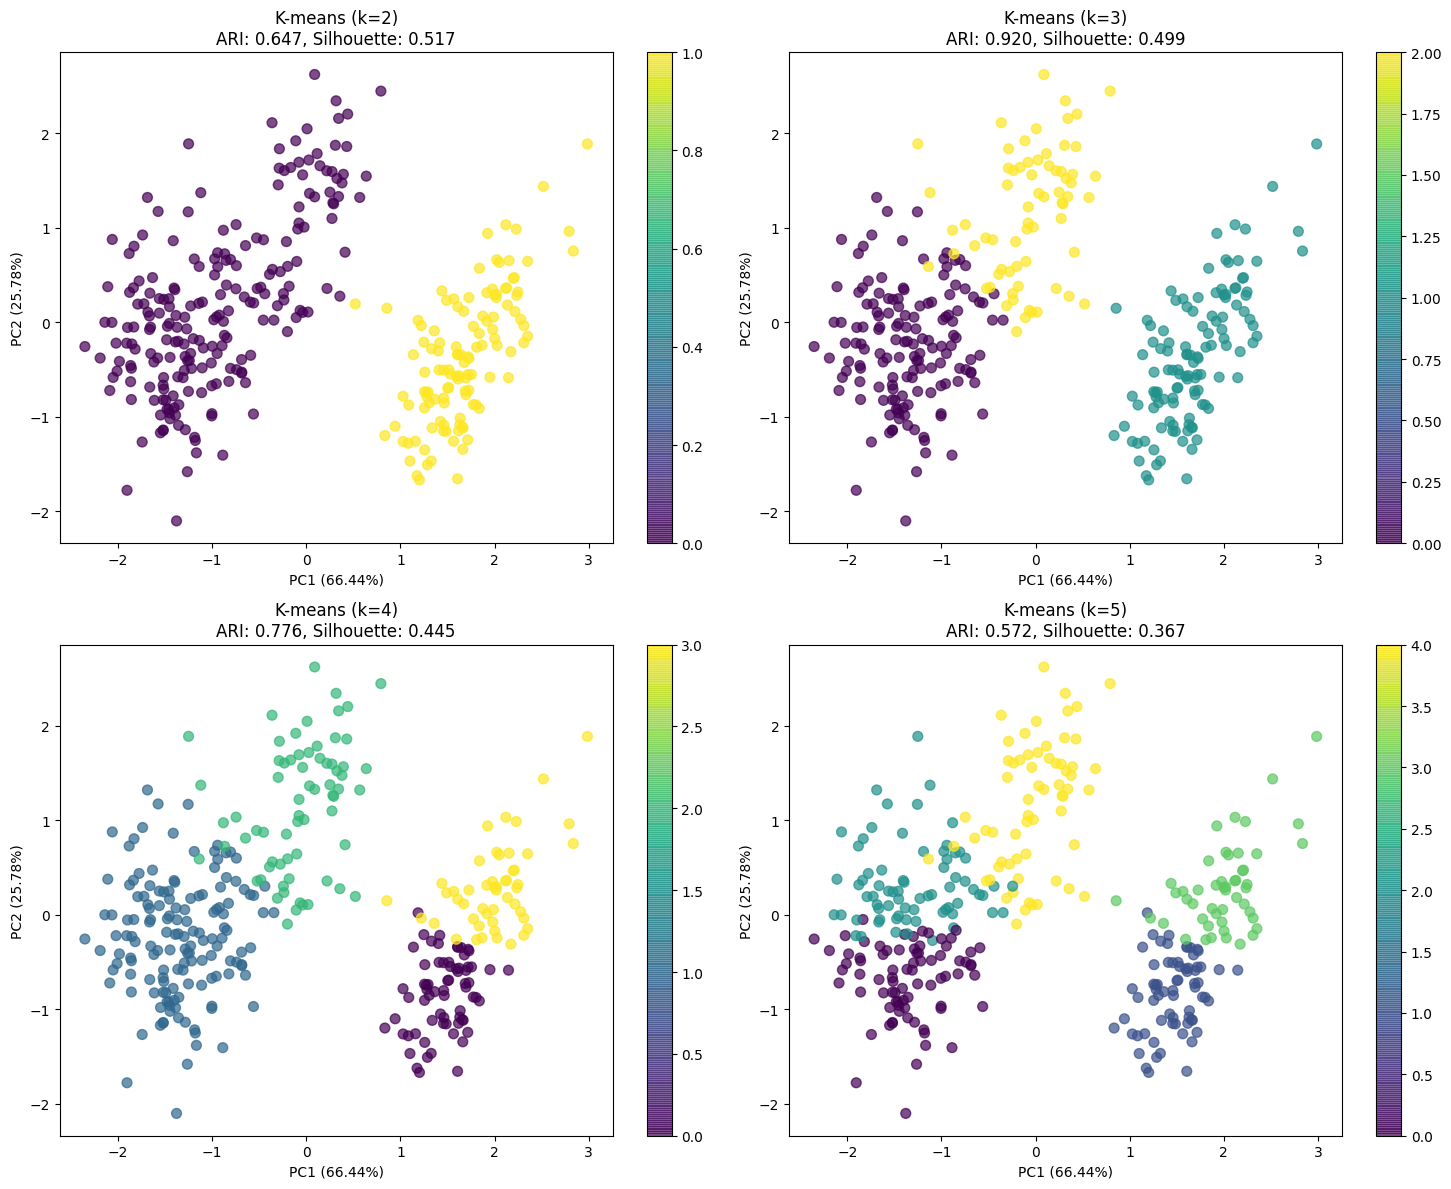

In [27]:
results = []

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)

    metrics = {}
    if len(np.unique(kmeans_labels)) > 1:
        metrics['silhouette'] = silhouette_score(X_scaled, kmeans_labels)
        metrics['calinski_harabasz'] = calinski_harabasz_score(X_scaled, kmeans_labels)
        metrics['davies_bouldin'] = davies_bouldin_score(X_scaled, kmeans_labels)
    else:
        metrics['silhouette'] = metrics['calinski_harabasz'] = metrics['davies_bouldin'] = np.nan

    if len(np.unique(kmeans_labels)) > 1:
        metrics['ari'] = adjusted_rand_score(true_labels, kmeans_labels)
        metrics['nmi'] = normalized_mutual_info_score(true_labels, kmeans_labels)
        metrics['fmi'] = fowlkes_mallows_score(true_labels, kmeans_labels)
    else:
        metrics['ari'] = metrics['nmi'] = metrics['fmi'] = np.nan

    cluster_stats = {}
    for label in np.unique(kmeans_labels):
        cluster_points = X_scaled[kmeans_labels == label]
        centroid = np.mean(cluster_points, axis=0)
        distances_to_center = np.linalg.norm(cluster_points - centroid, axis=1)
        
        cluster_stats[label] = {
            'size': len(cluster_points),
            'compactness': np.mean(distances_to_center),
            'intra_mean': np.mean(pdist(cluster_points)) if len(cluster_points) > 1 else 0,
            'radius': np.max(distances_to_center)
        }

    centroids = kmeans.cluster_centers_
    inter_distances = pdist(centroids)
    
    results.append({
        'k': k,
        'silhouette': metrics['silhouette'],
        'calinski_harabasz': metrics['calinski_harabasz'],
        'davies_bouldin': metrics['davies_bouldin'],
        'ari': metrics['ari'],
        'nmi': metrics['nmi'], 
        'fmi': metrics['fmi'],
        'mean_inter_distance': np.mean(inter_distances),
        'min_inter_distance': np.min(inter_distances),
        'labels': kmeans_labels,
        'model': kmeans
    })
    
comparison_df = pd.DataFrame({
    'K': [result['k'] for result in results],
    'Silhouette': [f"{result['silhouette']:.4f}" for result in results],
    'Calinski-Harabasz': [f"{result['calinski_harabasz']:.2f}" for result in results],
    'Davies-Bouldin': [f"{result['davies_bouldin']:.4f}" for result in results],
    'Ср. межкл. расст.': [f"{result['mean_inter_distance']:.4f}" for result in results],
    'Мин. межкл. расст.': [f"{result['min_inter_distance']:.4f}" for result in results],
    'ARI': [f"{result['ari']:.4f}" for result in results],
    'NMI': [f"{result['nmi']:.4f}" for result in results],
    'FMI': [f"{result['fmi']:.4f}" for result in results]
})

print("Сравнительная таблица метрик качества кластеризации K-means")
print(comparison_df.to_string(index=False))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, result in enumerate(results):
    scatter = axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=result['labels'], 
                             cmap='viridis', alpha=0.7, s=50)
    axes[i].set_title(f'K-means (k={result["k"]})\nARI: {result["ari"]:.3f}, Silhouette: {result["silhouette"]:.3f}')
    axes[i].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    axes[i].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.colorbar(scatter, ax=axes[i])

plt.tight_layout()
plt.show()

Исследование влияния количества кластеров k в методе k-means показало, что с увеличением k от 2 до 5 все внутренние метрики качества последовательно ухудшаются. Значение k=2, выбранное изначально, демонстрирует наилучшие результаты, в то время как дальнейшее увеличение k до 5 приводит к излишнему дроблению кластеров и снижению минимального межкластерного расстояния с 2.689 до 1.115, что ухудшает четкость границ между группами. Однако, внешние метрики имеют наибольшие значение при k=3. Это доказывает сделанный раннее вывод о существовании двух трудноразличимых классах, из-за которых ухудшаются внутренние метрики.